In [2]:
from dataclasses import dataclass
import matplotlib
import matplotlib.pyplot as plt
import torch
from torch import Tensor
from typing import Iterator

matplotlib.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

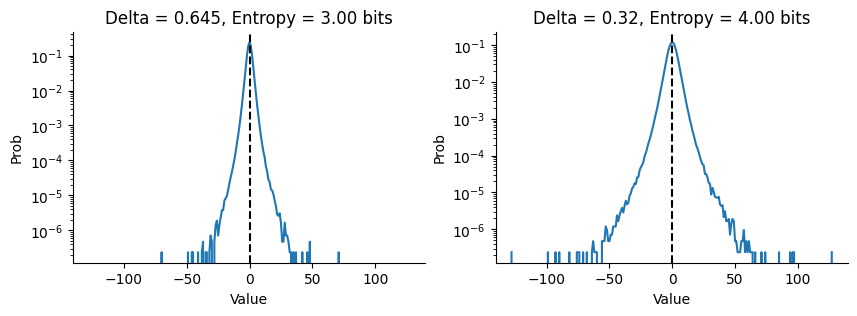

In [ ]:
delta = 0.65
dof = 5
torch.manual_seed(100)
samples = torch.distributions.StudentT(dof).sample((2**22,))

def quantize(x: Tensor, delta: float) -> Tensor:
    idx = x.div(delta).round().int()
    # assert -128 < idx.amin() <= idx.amax() <= 127, "distribution doesn't fit in INT8 without clipping"
    return idx.clamp(-128, 127)

def entropy(idx: Tensor) -> float:
    prob = torch.bincount(idx - idx.amin()) / idx.nelement()
    return prob.mul(prob.log2().nan_to_num(0)).sum().neg()

_, axs = plt.subplots(1, 2, figsize=(10, 3))
for ax, delta in zip(axs, [0.645, 0.32]):
    idx = quantize(samples, delta)
    ax.plot(torch.arange(-128, 128), torch.bincount(idx + 128, minlength=256) / idx.nelement())
    ax.set_title(f"Delta = {delta}, Entropy = {entropy(idx):.2f} bits")
    ax.set_xlabel("Value")
    ax.set_ylabel("Prob")
    ax.set_yscale("log")
    ax.axvline(0, color="k", ls="--");

Average length: 3.05 bits (vs entropy 3.00 bits)


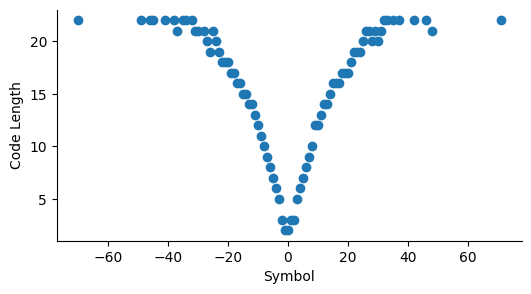

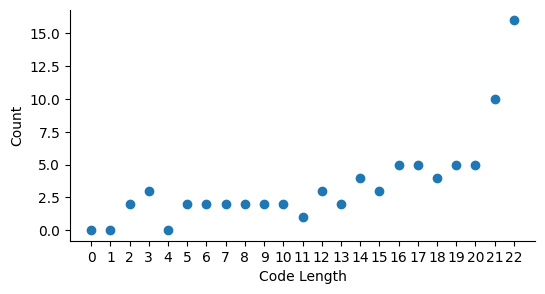

In [30]:
@dataclass
class Node:
    symbol: int | None
    children: tuple["Node", "Node"] | None
    frequency: int

    def __post_init__(self) -> None:
        assert (self.symbol is not None) != (self.children is not None), \
            "a node must either be terminal, or have children, never both"


def build_tree(idx: Tensor) -> Node:
    """Greedy algorithm for building the tree."""
    symbols = torch.arange(-128, 128)
    assert -128 < idx.amin() <= idx.amax() <= 127, "distribution doesn't fit in INT8 without clipping"
    frequencies = torch.bincount(idx + 128)
    nodes = [Node(int(s), None, int(f)) for s, f in zip(symbols, frequencies) if f]
    while len(nodes) >= 2:
        nodes = sorted(nodes, key=lambda n: n.frequency)
        a, b = nodes.pop(0), nodes.pop(0)
        nodes.append(Node(None, (a, b), a.frequency + b.frequency))
    return nodes[0]


def get_codes(node: Node, prefix: bytes = b'') -> Iterator[tuple[int, bytes]]:
    if node.symbol is not None:
        yield (node.symbol, prefix)
    if node.children is not None:
        for i, c in enumerate(node.children):
            yield from get_codes(c, prefix + b"01"[i:i+1])


def average_length(codes: dict[int, bytes], idx: Tensor) -> float:
    symbols = torch.arange(-128, 128)
    frequencies = torch.bincount(idx + 128)
    return sum(int(f) * len(codes[int(s)]) for s, f in zip(symbols, frequencies) if f) / idx.nelement()


idx = quantize(samples, 0.645)
codes = dict(get_codes(build_tree(idx)))
print(f"Average length: {average_length(codes, idx):.2f} bits (vs entropy {entropy(idx):.2f} bits)")

_, ax = plt.subplots(figsize=(6, 3))
ax.scatter(torch.tensor(list(codes.keys())), torch.tensor([len(c) for c in codes.values()]))
ax.set_xlabel("Symbol")
ax.set_ylabel("Code Length");

_, ax = plt.subplots(figsize=(6, 3))
lengths = torch.bincount(torch.tensor([len(c) for c in codes.values()]))
ax.scatter(torch.arange(len(lengths)), lengths)
ax.set_xlabel("Code Length")
ax.set_ylabel("Count")
ax.set_xticks(torch.arange(len(lengths)));